In [2]:
import os
from glob import glob

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from PIL import Image, ImageEnhance
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [21]:
collab = False
if collab:
    from google.colab import drive
    drive.mount('/content/drive')
    folder_path = 'drive/MyDrive/ai_data/data'
else: 
    folder_path = './data'

In [22]:
### HYPER PARAMS ###
batch_size = 16

In [23]:
def denormalize(img: torch.Tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(3, 1, 1)

    return img * std / mean

In [24]:
class BackgroundWithFlag(Dataset):
    def __init__(self, bg_path: str, flag_path: str):
        self.p_flag = 1
        self.p_augment_background = 0.7
        self.p_augment_flag = 0 # 0.7

        self.flag_min_size = 9
        self.flag_max_size = 19
        self.flag_max_shear = 0 # 0.4

        self.backgrounds = glob(os.path.join(bg_path, '*.jpg'))
        self.flags = glob(os.path.join(flag_path, '*.png'))

        self.all_augmentation = transforms.Compose([
            transforms.ToTensor(),
            transforms.GaussianBlur(3),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        self.background_resize = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.CenterCrop(224),
        ])

        self.background_augmentation = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(1.1, 1.2), shear=5),
            transforms.ColorJitter(brightness=(0.9, 1.1), contrast=(0.4, 1.5), saturation=(0.85, 1.6), hue=(-0.1, 0.1)),
        ])

    def __getitem__(self, index):
        background = Image.open(self.backgrounds[index]).convert("RGB")
        background = self.background_resize(background)

        if np.random.random() <= self.p_augment_background:
            background = self.background_augmentation(background)

        bbox = torch.tensor([-1, -1, -1, -1], dtype=torch.float32, device=device)
        flag_exists = 0
        composite_image = background

        if np.random.random() <= self.p_flag:
            flag = Image.open(np.random.choice(self.flags)).convert("RGBA")  # Flag with transparency

            if np.random.random() <= self.p_augment_flag:
                flag = self.augment_flag(flag)
            else:
                flag = flag.resize((np.random.randint(self.flag_min_size, self.flag_max_size),
                                    np.random.randint(self.flag_min_size, self.flag_max_size))).convert('RGBA')

            composite_image, flag_center, = self.paste_flag(background, flag)
            x1 = flag_center[0] - flag.size[0] / 2
            x2 = flag_center[0] + flag.size[0] / 2

            y1 = flag_center[1] - flag.size[1] / 2
            y2 = flag_center[1] + flag.size[1] / 2

            bbox = torch.tensor([x1, y1, x2, y2], dtype=torch.float32, device=device)

            flag_exists = 1

        composite_image = self.all_augmentation(composite_image)

        return (
            composite_image.to(device),
            {
                'boxes': bbox[None],
                'labels': torch.tensor([flag_exists], dtype=torch.int64, device=device)
            }
        )

    def augment_flag(self, flag: Image.Image):
        # Photometric Augmentations
        if np.random.random() >= 0.5:
            flag = flag.transpose(Image.FLIP_LEFT_RIGHT)

        if np.random.random() >= 0.5:
            flag = flag.transpose(Image.FLIP_TOP_BOTTOM)

        enhancer = ImageEnhance.Brightness(flag)
        flag = enhancer.enhance(np.random.uniform(0.8, 1.3))

        # Contrast adjustment
        enhancer = ImageEnhance.Contrast(flag)
        flag = enhancer.enhance(np.random.uniform(0.6, 1.3))

        # Saturation adjustment
        enhancer = ImageEnhance.Color(flag)
        flag = enhancer.enhance(np.random.uniform(0.7, 1.5))

        # Hue adjustment (we simulate this by shifting colors in HSV space)
        hue_shift = np.random.uniform(-0.5, 0.5)
        flag = flag.convert('HSV')
        channels = list(flag.split())
        channels[0] = channels[0].point(lambda h: (h + hue_shift * 255) % 255)
        flag = Image.merge('HSV', channels).convert('RGBA')

        # Affine Augmentation
        rand_w = np.random.randint(self.flag_min_size, self.flag_max_size)
        flag = flag.resize((rand_w, rand_w * 2))

        flag = flag.rotate(np.random.randint(0, 360), expand=True)

        # # Shear
        # width, height = flag.size
        # shear_factor = np.random.uniform(-self.flag_max_shear, self.flag_max_shear)  # Random shear factor
        # matrix = (1, shear_factor, 0, shear_factor, 1, 0)
        # flag = flag.transform((width, height), Image.AFFINE, matrix, resample=Image.BICUBIC)

        return flag

    def __len__(self):
        return len(self.backgrounds)

    @staticmethod
    def collate_fn(batch):
        return list(map(list, zip(*batch)))

    @staticmethod
    def paste_flag(background, flag):
        bg_w, bg_h = background.size
        flag_w, flag_h = flag.size

        max_x = bg_w - flag_w
        max_y = bg_h - flag_h
        x_pos = np.random.randint(0, max_x)  # max_x + flag_w to have the last half only
        y_pos = np.random.randint(0, max_y)  # max_y + flag_h to have the last half only

        background.paste(flag, (x_pos, y_pos), flag)

        flag_center = (x_pos + flag_w // 2, y_pos + flag_h // 2)
        return background, flag_center


dataset = BackgroundWithFlag(folder_path + '/desert', folder_path + '/flags')
dataloader = DataLoader(dataset, batch_size, True, collate_fn=BackgroundWithFlag.collate_fn)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5553105..2.2489078].


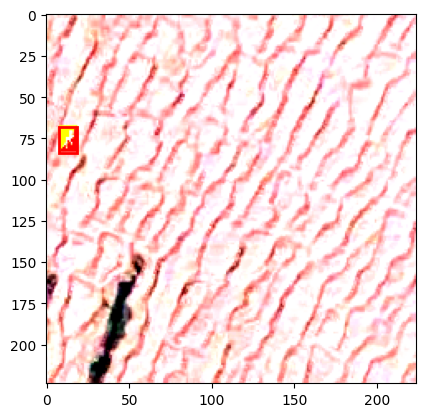

In [25]:
# testing the dataset
composite_image, pred_dict = dataset[0]
bbox, flag_exists = pred_dict['boxes'], pred_dict['labels']
composite_image = composite_image.permute(1, 2, 0).cpu().numpy()  # Move channels to the last dimension

fig, ax = plt.subplots(1)

ax.imshow(composite_image)
if flag_exists == 1:
    x1, y1, x2, y2 = bbox[0].cpu().numpy()
    rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)

In [26]:
model = models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights='DEFAULT')
model.roi_heads.box_predictor = FastRCNNPredictor(1024, 2)
# model.load_state_dict(torch.load(folder_path + '/checkpoints/flag_model.pth', weights_only=True))

model.to(device)
# todo fine tune the thresholds

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(320,), max_size=640, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): FrozenBatchNorm2d(16, eps=1e-05)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): FrozenBatchNorm2d(16, eps=1e-05)
          )
        )
      )
      (2): InvertedResidual(
        (block): 

In [27]:
opt = optim.SGD([p for p in model.parameters() if p.requires_grad], lr=1e-3, momentum=0.9, weight_decay=5e-4)
lr_schedule = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=opt,
    factor=0.5,
    patience=30,
    threshold=1e-5,
    threshold_mode='rel',
    min_lr=1e-7,
)

In [28]:
losses_track = [
    [], # classifier
    [], # box reg
    [], # losses objectness
    [], # rpn obj reg
    [] # total loss
]

In [29]:
epochs = 100

model.train()

for epoch in range(epochs):
    model.to(device)
    for img, pred_dict, in dataloader:
        # # mask
        # i = 0
        # while i < len(pred_dict):
        #     if pred_dict[i]['labels'] == 0:
        #         pred_dict.pop(i)
        #         img.pop(i)
        #     else:
        #         i += 1
        # if len(img) == 0: continue

        loss_dict = model(img, pred_dict)

        loss = torch.tensor([0.0], device=device)
        for i, l in enumerate(loss_dict.values()):
            loss += l
            losses_track[i].append(l.item())

        losses_track[-1].append(loss.item())
        opt.zero_grad()
        loss.backward()
        opt.step()
        print(f'total loss: {losses_track[-1][-1]}, lr: {opt.param_groups[0]["lr"]}')
        lr_schedule.step(losses_track[-1][-1])

    print(f'Epoch: {epoch}, loss: {losses_track[-1][-1]}')
    torch.save(model.cpu().state_dict(), folder_path + '/checkpoints/flag_model.pth')


total loss: 0.9998323321342468, lr: 0.001
total loss: 0.831656813621521, lr: 0.001
total loss: 0.672645092010498, lr: 0.001
total loss: 0.5854373574256897, lr: 0.001
total loss: 0.3568510413169861, lr: 0.001
total loss: 0.5429431796073914, lr: 0.001
total loss: 0.3615642189979553, lr: 0.001
total loss: 0.2828443944454193, lr: 0.001
total loss: 0.5227034091949463, lr: 0.001
total loss: 0.2541811764240265, lr: 0.001
total loss: 0.26985931396484375, lr: 0.001
total loss: 0.3899093270301819, lr: 0.001
total loss: 0.2873021364212036, lr: 0.001
total loss: 0.29132065176963806, lr: 0.001
total loss: 0.36218202114105225, lr: 0.001
total loss: 0.4138332009315491, lr: 0.001
total loss: 0.49893730878829956, lr: 0.001
total loss: 0.5084540247917175, lr: 0.001
total loss: 0.40078696608543396, lr: 0.001
total loss: 0.1944841891527176, lr: 0.001
total loss: 0.640188992023468, lr: 0.001
total loss: 0.2865230441093445, lr: 0.001
total loss: 0.24552027881145477, lr: 0.001
total loss: 0.3490617275238037,

KeyboardInterrupt: 

In [34]:
torch.save(model.cpu().state_dict(), './data/checkpoints/flag_model.pth')

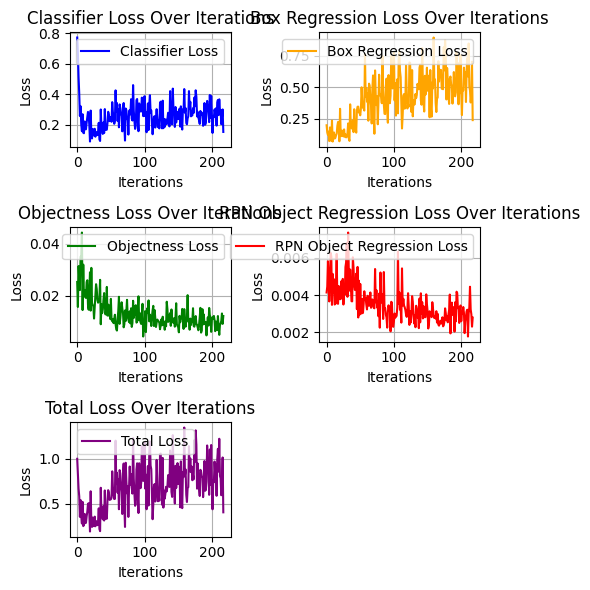

In [30]:
# Create a figure and a 3x2 grid of subplots (since we now have 5 loss types)
fig, axs = plt.subplots(3, 2, figsize=(5, 6))

# Classifier Loss
axs[0, 0].plot(range(len(losses_track[0])), losses_track[0], color='blue', label='Classifier Loss')
axs[0, 0].set_title('Classifier Loss Over Iterations')
axs[0, 0].set_xlabel('Iterations')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Box Regression Loss
axs[0, 1].plot(range(len(losses_track[1])), losses_track[1], color='orange', label='Box Regression Loss')
axs[0, 1].set_title('Box Regression Loss Over Iterations')
axs[0, 1].set_xlabel('Iterations')
axs[0, 1].set_ylabel('Loss')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Objectness Loss
axs[1, 0].plot(range(len(losses_track[2])), losses_track[2], color='green', label='Objectness Loss')
axs[1, 0].set_title('Objectness Loss Over Iterations')
axs[1, 0].set_xlabel('Iterations')
axs[1, 0].set_ylabel('Loss')
axs[1, 0].legend()
axs[1, 0].grid(True)

# RPN Object Regression Loss
axs[1, 1].plot(range(len(losses_track[3])), losses_track[3], color='red', label='RPN Object Regression Loss')
axs[1, 1].set_title('RPN Object Regression Loss Over Iterations')
axs[1, 1].set_xlabel('Iterations')
axs[1, 1].set_ylabel('Loss')
axs[1, 1].legend()
axs[1, 1].grid(True)

# Total Loss
axs[2, 0].plot(range(len(losses_track[4])), losses_track[4], color='purple', label='Total Loss')
axs[2, 0].set_title('Total Loss Over Iterations')
axs[2, 0].set_xlabel('Iterations')
axs[2, 0].set_ylabel('Loss')
axs[2, 0].legend()
axs[2, 0].grid(True)

# Hide the unused subplot (bottom right)
axs[2, 1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()


In [20]:
def get_frame_at_time(video_path, time_in_seconds, output_path=None):
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    
    # Calculate the frame number to capture (video FPS * time in seconds)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_number = int(fps * time_in_seconds)
    
    # Set the video capture to the specific frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the frame
    success, frame = cap.read()
    
    if success:
        if output_path:
            # Save the frame as an image
            cv2.imwrite(output_path, frame)
        # Return the frame as a numpy array
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return frame
    else:
        print("Failed to capture frame")
        return None

In [21]:
transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((256, 256)),
            transforms.CenterCrop(224),
            transforms.GaussianBlur(3),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        
# sample_Img = Image.open('./data/test/img_1.png').convert("RGB")
# sample_img = get_frame_at_time('./data/test/noury_vid.MP4', 200)
# sample_img = transform(sample_img)
# plt.imshow(sample_img.permute(1,2,0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7558887..1.2329576].


tensor([0.1594, 0.1035, 0.0912], grad_fn=<IndexBackward0>)


Text(0.5, 1.0, 'Denormalized Image')

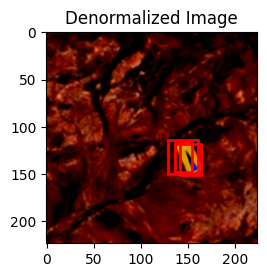

In [40]:
sample_img, _ = dataset[5]

model.eval()

pred_dict = model(sample_img[None])[0]
bbox, scores = pred_dict['boxes'].detach(), pred_dict['scores']
print(scores)
bbox = bbox[scores > 0]
denormalized_img = denormalize(sample_img)

plt.figure(figsize=(6, 6))
plt.subplot(121)
plt.imshow(denormalized_img.permute(1, 2, 0))
if(len(bbox) > 0):
    for box in bbox:
        # box = box[0]
        plt.gca().add_patch(
            patches.Rectangle(box[:2], box[2] - box[0], box[3] - box[1], fill=False, edgecolor='red', linewidth=2)
        )

plt.title('Denormalized Image')